### ШАГ 1 - Небольшой анализ полученных данных


In [15]:
import pandas as pd
import numpy as np

path = '/kaggle/input/datasets/nikolasking/data-ease/prepared_train_data.csv'
data = pd.read_csv(path)

print(f"Размер данных: {data.shape}")
print(f"Колонки: {data.columns.tolist()}")
print("-" * 50)
print("\nТипы данных:")
print(data.dtypes)

Размер данных: (856700, 15)
Колонки: ['userId', 'movieId', 'score', 'title', 'genres', 'popularity', 'age', 'rating', 'runtimeMinutes', 'num_translations', 'main_region', 'is_multiregional', 'actors_list', 'director_name', 'cluster']
--------------------------------------------------

Типы данных:
userId                int64
movieId               int64
score               float64
title                object
genres               object
popularity          float64
age                 float64
rating              float64
runtimeMinutes      float64
num_translations    float64
main_region          object
is_multiregional     object
actors_list          object
director_name        object
cluster             float64
dtype: object


In [2]:
data.head()

,userId,movieId,score,title,genres,popularity,age,rating,runtimeMinutes,num_translations,main_region,is_multiregional,actors_list,director_name,cluster
0,28,70,0.199366,From Dusk Till Dawn,"['Action', 'Comedy', 'Horror', 'Thriller']",0.000446,29.0,3.202508,108.0,51.0,CA,True,"['Harvey Keitel', 'George Clooney', 'Juliette ...",Robert Rodriguez,23.0
1,28,2424,0.190685,You've Got Mail,"['Comedy', 'Romance']",0.000398,27.0,3.053162,119.0,58.0,CA,True,"['Tom Hanks', 'Meg Ryan', 'Greg Kinnear', 'Par...",NaN,23.0
2,28,31878,0.183384,Kung Fu Hustle (Gong fu),"['Action', 'Comedy']",0.000261,21.0,3.561326,99.0,55.0,IN,True,['Stephen Chow'],Stephen Chow,3.0
3,28,37729,0.169491,Corpse Bride,"['Animation', 'Comedy', 'Fantasy', 'Musical', ...",0.000436,20.0,3.334100,77.0,60.0,CA,True,"['Johnny Depp', 'Helena Bonham Carter', 'Emily...",Tim Burton,23.0
4,28,5014,0.167917,I Am Sam,['Drama'],0.000189,24.0,3.365230,132.0,40.0,ES,True,"['Sean Penn', 'Michelle Pfeiffer', 'Dakota Fan...",NaN,23.0


In [3]:
nan_analysis = pd.DataFrame({
    'count_nan': data.isnull().sum(),
    'pct_nan': (data.isnull().sum() / len(data) * 100).round(2)
}).sort_values('pct_nan', ascending=False)

print("Пропущенные значения:")
print(nan_analysis[nan_analysis.count_nan > 0])
print(f"\nВсего строк: {len(data)}")
print(f"Колонок с NaN: {(nan_analysis.count_nan > 0).sum()}")

Пропущенные значения:
                  count_nan  pct_nan
director_name        475103    55.46
is_multiregional      24377     2.85
main_region           24377     2.85
num_translations      24377     2.85
actors_list           24377     2.85
runtimeMinutes        24377     2.85
age                     483     0.06
cluster                  36     0.00

Всего строк: 856700
Колонок с NaN: 8


In [4]:
print(f"Уникальных пользователей: {data['userId'].nunique()}")
print(f"Уникальных фильмов: {data['movieId'].nunique()}")
print(f"Строк на пользователя (среднее): {len(data) / data['userId'].nunique():.1f}")

# Проверяем дубликаты (пара user-movie должна быть уникальной)
dupes = data.duplicated(subset=['userId', 'movieId']).sum()
print(f"\nДубликатов (userId, movieId): {dupes}")

Уникальных пользователей: 8567
Уникальных фильмов: 5333
Строк на пользователя (среднее): 100.0

Дубликатов (userId, movieId): 0


In [7]:
# Смотрим на реальный формат
print("Пример genres:", data['genres'].iloc[0])
print("Тип genres:", type(data['genres'].iloc[0]))
print()
print("Пример actors_list:", data['actors_list'].iloc[0])
print()
print("Пример director_name:", data['director_name'].iloc[:5].tolist())
print("NaN в director_name:", data['director_name'].isnull().sum())

Пример genres: ['Action', 'Comedy', 'Horror', 'Thriller']
Тип genres: <class 'str'>

Пример actors_list: ['Harvey Keitel', 'George Clooney', 'Juliette Lewis', 'Quentin Tarantino', 'Salma Hayek', 'Cheech Marin', 'Danny Trejo', 'Fred Williamson']

Пример director_name: ['Robert Rodriguez', nan, 'Stephen Chow', 'Tim Burton', nan]
NaN в director_name: 475103


### ШАГ 2 - Загрузка датасета для создания label и обучение моделей на основе имеющихся данных

In [10]:
df = pd.read_csv('/kaggle/input/datasets/nikolasking/user-item-data-recsys/ratings.csv', 
                   usecols=['userId', 'movieId', 'rating', 'timestamp'])

In [11]:
display(df.dtypes)
display(df.head())

userId         int64
movieId        int64
rating       float64
timestamp      int64
dtype: object

,userId,movieId,rating,timestamp
0,1,17,4.0,944249077
1,1,25,1.0,944250228
2,1,29,2.0,943230976
3,1,30,5.0,944249077
4,1,32,5.0,943228858


In [12]:
df.rating.unique()

array([4. , 1. , 2. , 5. , 3. , 3.5, 0.5, 4.5, 2.5, 1.5])

In [13]:
df.rating = df.rating.astype(int)

In [14]:
# Разделим на трейн и тест по 01.01.2018
train_df = df.loc[(df.timestamp < 1514764800)].copy()
test_df = df.loc[(df.timestamp >= 1514764800)].copy()

In [15]:
train_users = train_df.userId.unique()
test_users = test_df.userId.unique()

# Возьмем только тех людей, которые попали и в трейн, и в тест
all_included = np.intersect1d(train_users, test_users)

n_users = all_included.shape[0]

# В трейне и тесте выделим только тех, кто есть и там, и там
train_df = train_df.loc[train_df.userId.isin(all_included)].copy()
test_df = test_df.loc[test_df.userId.isin(all_included)].copy()

# Сгруппируем все интеракции по пользователям
train_grouped = train_df.groupby('userId').apply(
    lambda x: [(t1, t2) for t1, t2 in sorted(zip(x.movieId, 
                                                 x.rating), key=lambda x: x[1])]
).reset_index()
train_grouped.rename({0:'train_interactions'}, axis=1, inplace=True)

test_grouped = test_df.groupby('userId').apply(
    lambda x: [(t1, t2) for t1, t2 in sorted(zip(x.movieId,
                                                         x.rating), key=lambda x: x[1])]
).reset_index()
test_grouped.rename({0:'test_interactions'}, axis=1, inplace=True)

train_grouped.head()

/tmp/ipykernel_55/506008888.py:14: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  train_grouped = train_df.groupby('userId').apply(
/tmp/ipykernel_55/506008888.py:20: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  test_grouped = test_df.groupby('userId').apply(


,userId,train_interactions
0,28,"[(8666, 0), (54, 1), (75, 1), (160, 1), (174, ..."
1,35,"[(1247, 2), (1590, 2), (1917, 2), (6365, 2), (..."
2,100,"[(49274, 1), (60069, 1), (34, 2), (1127, 2), (..."
3,111,"[(104, 2), (288, 2), (356, 2), (2424, 2), (316..."
4,140,"[(94959, 2), (168254, 2), (6870, 3), (56587, 3..."


In [16]:
joined = train_grouped.merge(test_grouped)
joined

,userId,train_interactions,test_interactions
0,28,"[(8666, 0), (54, 1), (75, 1), (160, 1), (174, ...","[(4125, 0), (4138, 0), (261759, 1), (5679, 2),..."
1,35,"[(1247, 2), (1590, 2), (1917, 2), (6365, 2), (...","[(2513, 2), (5218, 2), (5618, 2), (7115, 2), (..."
2,100,"[(49274, 1), (60069, 1), (34, 2), (1127, 2), (...","[(8533, 1), (222477, 1), (608, 2), (1183, 2), ..."
3,111,"[(104, 2), (288, 2), (356, 2), (2424, 2), (316...","[(168330, 3), (158238, 4)]"
4,140,"[(94959, 2), (168254, 2), (6870, 3), (56587, 3...","[(160954, 3), (176101, 5), (177593, 5), (17776..."
...,...,...,...
8562,200898,"[(4306, 3), (115713, 3), (122904, 3), (152081,...","[(2662, 2), (6534, 3), (78469, 3), (85414, 3),..."
8563,200915,"[(88267, 0), (18, 1), (592, 1), (1676, 1), (21...","[(60069, 5)]"
8564,200920,"[(159721, 0), (56949, 1), (63992, 1), (72407, ...","[(179819, 3), (122906, 4), (122912, 5)]"
8565,200930,"[(2706, 0), (4718, 0), (122904, 0), (171729, 0...","[(112556, 0), (140880, 0), (176149, 0), (92259..."


Проверяем базовую статистику joined:

In [17]:
print(f"Пользователей в joined: {len(joined)}")
print(f"Совпадает с n_users: {len(joined) == n_users}")
print()

# Длина train_interactions у каждого пользователя
train_lengths = joined['train_interactions'].apply(len)
test_lengths = joined['test_interactions'].apply(len)

print("Длина train_interactions:")
print(train_lengths.describe())
print()
print("Длина test_interactions:")
print(test_lengths.describe())

Пользователей в joined: 8567
Совпадает с n_users: True

Длина train_interactions:
count     8567.000000
mean       428.277343
std        570.826992
min          1.000000
25%         96.000000
50%        249.000000
75%        555.000000
max      19042.000000
Name: train_interactions, dtype: float64

Длина test_interactions:
count     8567.000000
mean       136.651453
std        305.066396
min          1.000000
25%         14.000000
50%         46.000000
75%        144.000000
max      14290.000000
Name: test_interactions, dtype: float64


Сверяем userId из joined с userId из prepared_train_data:

In [19]:
joined_users = set(joined['userId'].unique())
data_users = set(data['userId'].unique())

print(f"Пользователей в joined:              {len(joined_users)}")
print(f"Пользователей в prepared_train_data: {len(data_users)}")
print(f"Пересечение:                         {len(joined_users & data_users)}")
print(f"Есть в joined, нет в data:           {len(joined_users - data_users)}")
print(f"Есть в data, нет в joined:           {len(data_users - joined_users)}")

Пользователей в joined:              8567
Пользователей в prepared_train_data: 8567
Пересечение:                         8567
Есть в joined, нет в data:           0
Есть в data, нет в joined:           0


### Создаем label

In [20]:
# Словарь: userId -> множество фильмов из теста
test_items_dict = {
    row.userId: set(t[0] for t in row.test_interactions)
    for row in joined.itertuples()
}

# Словарь: userId -> количество фильмов в трейне
num_interactions_dict = {
    row.userId: len(row.train_interactions)
    for row in joined.itertuples()
}

# Проставляем label и num_interactions
data['label'] = data.apply(
    lambda row: 1 if row['movieId'] in test_items_dict.get(row['userId'], set()) else 0,
    axis=1
)
data['num_interactions'] = data['userId'].map(num_interactions_dict)

print(f"Позитивных (label=1): {data['label'].sum()}")
print(f"Негативных (label=0): {(data['label']==0).sum()}")
print(f"Доля позитивных:      {data['label'].mean()*100:.2f}%")
print(f"\nnum_interactions — пропуски: {data['num_interactions'].isnull().sum()}")

Позитивных (label=1): 110747
Негативных (label=0): 745953
Доля позитивных:      12.93%

num_interactions — пропуски: 0


In [23]:
print("Текущие колонки:")
print(data.columns.tolist())
print()

# Что уже есть и в каком состоянии
print("Числовые признаки — пропуски:")
for col in ['score', 'popularity', 'age', 'rating', 'runtimeMinutes', 
            'num_translations', 'cluster', 'num_interactions']:
    nans = data[col].isnull().sum()
    print(f"  {col:20s}: {nans} NaN ({nans/len(data)*100:.2f}%)")

print()
print("Категориальные признаки — пропуски:")
for col in ['main_region', 'is_multiregional', 'director_name']:
    nans = data[col].isnull().sum()
    print(f"  {col:20s}: {nans} NaN ({nans/len(data)*100:.2f}%)")

print()
# genres — строка-список, нужно будет обработать
print("Пример genres:", data['genres'].iloc[0], type(data['genres'].iloc[0]))

Текущие колонки:
['userId', 'movieId', 'score', 'title', 'genres', 'popularity', 'age', 'rating', 'runtimeMinutes', 'num_translations', 'main_region', 'is_multiregional', 'actors_list', 'director_name', 'cluster', 'label', 'num_interactions']

Числовые признаки — пропуски:
  score               : 0 NaN (0.00%)
  popularity          : 0 NaN (0.00%)
  age                 : 483 NaN (0.06%)
  rating              : 0 NaN (0.00%)
  runtimeMinutes      : 24377 NaN (2.85%)
  num_translations    : 24377 NaN (2.85%)
  cluster             : 36 NaN (0.00%)
  num_interactions    : 0 NaN (0.00%)

Категориальные признаки — пропуски:
  main_region         : 24377 NaN (2.85%)
  is_multiregional    : 24377 NaN (2.85%)
  director_name       : 475103 NaN (55.46%)

Пример genres: ['Action', 'Comedy', 'Horror', 'Thriller'] <class 'str'>


### Обработка признаков:

- director_name (55% NaN) - слишком много пропусков, чтобы использовать напрямую. Сделаем бинарный признак has_director.
- genres — строка вида "['Action', 'Comedy', 'Horror', 'Thriller']", нужно распарсить и сделать бинарные колонки или взять первый жанр.
- runtimeMinutes, num_translations, main_region (2.85% NaN) - одна группа фильмов без метаданных. Заполним медианой / модой.

In [65]:
import ast

bdf = data.copy()

bdf['age'] = bdf['age'].fillna(bdf['age'].median())
bdf['runtimeMinutes'] = bdf['runtimeMinutes'].fillna(bdf['runtimeMinutes'].median())
bdf['num_translations'] = bdf['num_translations'].fillna(bdf['num_translations'].median())
bdf['cluster'] = bdf['cluster'].fillna(bdf['cluster'].mode()[0])
bdf['main_region'] = bdf['main_region'].fillna('UNKNOWN')
bdf['is_multiregional'] = bdf['is_multiregional'].apply(lambda x: 0 if x == 0.0 else 1)
bdf['has_director'] = bdf['director_name'].notna().astype(int)

# парсим строку-список, берем первый как main
def parse_first_main(g):
    try:
        main_list = ast.literal_eval(g)
        return main_list[0] if main_list else 'Unknown'
    except:
        return 'Unknown'

bdf['main_genre'] = bdf['genres'].apply(parse_first_main)
actor_counts = bdf['actors_list'].apply(parse_first_main).value_counts()
bdf['main_actor_popularity'] = bdf['actors_list'].apply(
    lambda x: actor_counts.get(parse_first_main(x), 0)
)

# Проверка: все пропуски закрыты?
check_cols = ['age', 'runtimeMinutes', 'num_translations', 'cluster',
              'main_region', 'is_multiregional', 'main_genre', 'main_actor_popularity']
print("Пропуски после обработки:")
for col in check_cols:
    nans = bdf[col].isnull().sum()
    print(f"  {col:20s}: {nans} NaN")

Пропуски после обработки:
  age                 : 0 NaN
  runtimeMinutes      : 0 NaN
  num_translations    : 0 NaN
  cluster             : 0 NaN
  main_region         : 0 NaN
  is_multiregional    : 0 NaN
  main_genre          : 0 NaN
  main_actor_popularity: 0 NaN


In [66]:
# Признаки для модели
FEATURES = [
    'score',            # EASE score - главный признак
    'popularity',       # популярность фильма
    'age',              # возраст фильма
    'rating',           # средний рейтинг
    'runtimeMinutes',   # длительность
    'num_translations', # количество переводов
    'cluster',          # кластер из эмбеддингов тегов
    'is_multiregional', # мультирегиональный ли
    'has_director',     # есть ли режиссёр в метаданных
    'num_interactions', # активность пользователя в трейне
    'main_genre',       # главный жанр (категориальный)
    'main_region',      # регион (категориальный)
    'main_actor_popularity'        # популярность актера (числовой)
]

print("Итоговые признаки:", FEATURES)
print(f"\nРазмер датасета: {bdf.shape}")
print(f"\nПример данных:")
display(bdf[FEATURES + ['label']].head())

# Типы признаков
print("\nТипы:")
print(bdf[FEATURES].dtypes)

Итоговые признаки: ['score', 'popularity', 'age', 'rating', 'runtimeMinutes', 'num_translations', 'cluster', 'is_multiregional', 'has_director', 'num_interactions', 'main_genre', 'main_region', 'main_actor_popularity']

Размер датасета: (856700, 20)

Пример данных:


,score,popularity,age,rating,runtimeMinutes,num_translations,cluster,is_multiregional,has_director,num_interactions,main_genre,main_region,main_actor_popularity,label
0,0.199366,0.000446,29.0,3.202508,108.0,51.0,23.0,1,1,2627,Action,CA,2199,0
1,0.190685,0.000398,27.0,3.053162,119.0,58.0,23.0,1,0,2627,Comedy,CA,22306,1
2,0.183384,0.000261,21.0,3.561326,99.0,55.0,3.0,1,1,2627,Action,IN,269,0
3,0.169491,0.000436,20.0,3.334100,77.0,60.0,23.0,1,1,2627,Animation,CA,13495,0
4,0.167917,0.000189,24.0,3.365230,132.0,40.0,23.0,1,0,2627,Drama,ES,1927,0



Типы:
score                    float64
popularity               float64
age                      float64
rating                   float64
runtimeMinutes           float64
num_translations         float64
cluster                  float64
is_multiregional           int64
has_director               int64
num_interactions           int64
main_genre                object
main_region               object
main_actor_popularity      int64
dtype: object


### Train/test split по пользователям:

In [67]:
from sklearn.model_selection import GroupShuffleSplit

# Делим по пользователям (GroupShuffleSplit гарантирует,
# что один userId не попадет в обе части)
gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(gss.split(bdf, groups=bdf['userId']))

train_bdf = bdf.iloc[train_idx].copy()
test_bdf = bdf.iloc[test_idx].copy()

print(f"Train: {len(train_bdf)} строк, {train_bdf['userId'].nunique()} пользователей")
print(f"Test:  {len(test_bdf)} строк, {test_bdf['userId'].nunique()} пользователей")
print()
print(f"Доля label=1 в train: {train_bdf['label'].mean()*100:.2f}%")
print(f"Доля label=1 в test:  {test_bdf['label'].mean()*100:.2f}%")
print()
# Убеждаемся что пользователи не пересекаются
overlap = set(train_bdf['userId']) & set(test_bdf['userId'])
print(f"Пересечение пользователей train/test: {len(overlap)}")

Train: 642500 строк, 6425 пользователей
Test:  214200 строк, 2142 пользователей

Доля label=1 в train: 12.87%
Доля label=1 в test:  13.11%

Пересечение пользователей train/test: 0


Балансировка классов (undersampling как в семинаре)

In [68]:
# Позитивов 12.93% - дисбаланс есть, но не такой критичный как в семинаре (0.74%)
# Всё равно делаем undersampling для устойчивости обучения
pos = train_bdf[train_bdf['label'] == 1].copy()
neg = train_bdf[train_bdf['label'] == 0].sample(pos.shape[0] * 4, random_state=42)

train_balanced = pd.concat([pos, neg]).sample(frac=1, random_state=42)

print(f"После балансировки:")
print(f"Позитивов: {train_balanced['label'].sum()}")
print(f"Негативов: {(train_balanced['label']==0).sum()}")
print(f"Итого:     {len(train_balanced)}")
print(f"Доля label=1: {train_balanced['label'].mean()*100:.2f}%")

После балансировки:
Позитивов: 82675
Негативов: 330700
Итого:     413375
Доля label=1: 20.00%


### Категориальные признаки и обучение LightGBM:

In [69]:
from lightgbm import LGBMClassifier

# Переводим категориальные в тип category (LightGBM умеет с ними работать нативно)
for col in ['main_genre', 'main_region']:
    train_balanced[col] = train_balanced[col].astype('category')
    test_bdf[col] = test_bdf[col].astype('category')

clf = LGBMClassifier(
    max_depth=3,
    n_estimators=100,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

clf.fit(
    X=train_balanced[FEATURES],
    y=train_balanced['label']
)

# Предсказания на тесте
test_bdf['boosting_preds'] = clf.predict_proba(test_bdf[FEATURES])[:, 1]

print("Модель обучена!")
print(f"Предсказания: min={test_bdf['boosting_preds'].min():.4f}, "
      f"max={test_bdf['boosting_preds'].max():.4f}, "
      f"mean={test_bdf['boosting_preds'].mean():.4f}")

Модель обучена!
Предсказания: min=0.0512, max=0.7939, mean=0.1973


Метрики

In [70]:
from sklearn.metrics import roc_auc_score as auc
import numpy as np

# AUC
print("=" * 50)
print("AUC:")
print(f"  EASE baseline:    {auc(test_bdf['label'], test_bdf['score']):.4f}")
print(f"  EASE + LightGBM:  {auc(test_bdf['label'], test_bdf['boosting_preds']):.4f}")
print()

# Метрики ранжирования
def dcg(scores):
    return np.sum((2**scores - 1) / np.log2(np.arange(len(scores)) + 2))

def ndcg_metric(gt_items, predicted, k=10):
    predicted = predicted[:k]
    relevance = np.array([1 if x in gt_items else 0 for x in predicted])
    rank_dcg = dcg(relevance)
    ideal_dcg = dcg(np.sort(relevance)[::-1])
    return rank_dcg / ideal_dcg if ideal_dcg > 0 else 0

def precision_at_k(gt_items, predicted, k=10):
    predicted = predicted[:k]
    return len(set(predicted) & set(gt_items)) / k

def recall_at_k(gt_items, predicted, k=50):
    if len(gt_items) == 0:
        return 0.0
    predicted = predicted[:k]
    return len(set(predicted) & set(gt_items)) / len(gt_items)

def evaluate(df, score_col, k_ndcg=10, k_prec=10, k_rec=10):
    ndcg_list, prec_list, rec_list = [], [], []
    
    for user_id, group in df.groupby('userId'):
        true_items = set(group[group['label'] == 1]['movieId'])
        if len(true_items) == 0:
            continue
        # Сортируем кандидатов по score и берем movieId
        recs = group.sort_values(score_col, ascending=False)['movieId'].tolist()
        
        ndcg_list.append(ndcg_metric(true_items, recs, k=k_ndcg))
        prec_list.append(precision_at_k(true_items, recs, k=k_prec))
        rec_list.append(recall_at_k(true_items, recs, k=k_rec))
    
    return np.mean(ndcg_list), np.mean(prec_list), np.mean(rec_list)

print("=" * 50)
print("Метрики ранжирования:")
for model_name, col in [('EASE baseline', 'score'), ('EASE + LightGBM', 'boosting_preds')]:
    ndcg, prec, rec = evaluate(test_bdf, col)
    print(f"\n{model_name}:")
    print(f"  @10: NDCG={ndcg:.4f}, P={prec:.4f}, R={rec:.4f}")

AUC:
  EASE baseline:    0.5540
  EASE + LightGBM:  0.6403

Метрики ранжирования:

EASE baseline:
  @10: NDCG=0.5117, P=0.2503, R=0.1906

EASE + LightGBM:
  @10: NDCG=0.5756, P=0.2855, R=0.2448


### LightGBM Ranker

In [71]:
from lightgbm import LGBMRanker
import lightgbm as lgb

# Ранкер требует данные отсортированные по userId
# и размеры групп (сколько кандидатов у каждого пользователя)
train_ranker = train_bdf.sort_values('userId').reset_index(drop=True)
test_ranker = test_bdf.sort_values('userId').reset_index(drop=True)

# Размеры групп - у каждого пользователя по 100 кандидатов
train_groups = train_ranker.groupby('userId').size().values
test_groups = test_ranker.groupby('userId').size().values

print(f"Train: {len(train_groups)} пользователей, "
      f"средний размер группы: {train_groups.mean():.1f}")
print(f"Test:  {len(test_groups)} пользователей, "
      f"средний размер группы: {test_groups.mean():.1f}")
print(f"Позитивов в train: {train_ranker['label'].sum()}")

# Категориальные признаки
for col in ['main_genre', 'main_region']:
    train_ranker[col] = train_ranker[col].astype('category')
    test_ranker[col] = test_ranker[col].astype('category')

Train: 6425 пользователей, средний размер группы: 100.0
Test:  2142 пользователей, средний размер группы: 100.0
Позитивов в train: 82675


In [72]:
%%time

ranker = LGBMRanker(
    objective='lambdarank',
    n_estimators=500,
    max_depth=3,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

ranker.fit(
    X=train_ranker[FEATURES],
    y=train_ranker['label'],
    group=train_groups,
    eval_set=[(test_ranker[FEATURES], test_ranker['label'])],
    eval_group=[test_groups],
    callbacks=[lgb.log_evaluation(50)]
)

# Предсказания
test_bdf['ranker_preds'] = ranker.predict(test_bdf[FEATURES])
print("\nРанкер обучен!")

[50]	valid_0's ndcg@1: 0.466387	valid_0's ndcg@2: 0.447765	valid_0's ndcg@3: 0.440248	valid_0's ndcg@4: 0.436334	valid_0's ndcg@5: 0.432991
[100]	valid_0's ndcg@1: 0.469655	valid_0's ndcg@2: 0.451869	valid_0's ndcg@3: 0.443941	valid_0's ndcg@4: 0.438958	valid_0's ndcg@5: 0.434712
[150]	valid_0's ndcg@1: 0.46732	valid_0's ndcg@2: 0.453081	valid_0's ndcg@3: 0.444168	valid_0's ndcg@4: 0.437292	valid_0's ndcg@5: 0.433713
[200]	valid_0's ndcg@1: 0.471989	valid_0's ndcg@2: 0.456551	valid_0's ndcg@3: 0.445121	valid_0's ndcg@4: 0.439035	valid_0's ndcg@5: 0.435257
[250]	valid_0's ndcg@1: 0.47479	valid_0's ndcg@2: 0.456282	valid_0's ndcg@3: 0.446469	valid_0's ndcg@4: 0.440578	valid_0's ndcg@5: 0.437336
[300]	valid_0's ndcg@1: 0.474323	valid_0's ndcg@2: 0.4588	valid_0's ndcg@3: 0.447349	valid_0's ndcg@4: 0.440911	valid_0's ndcg@5: 0.439052
[350]	valid_0's ndcg@1: 0.471522	valid_0's ndcg@2: 0.458033	valid_0's ndcg@3: 0.447105	valid_0's ndcg@4: 0.441022	valid_0's ndcg@5: 0.440373
[400]	valid_0's nd

In [73]:
print("=" * 60)
print("AUC:")
print(f"  EASE baseline:    {auc(test_bdf['label'], test_bdf['score']):.4f}")
print(f"  EASE + Classifier:{auc(test_bdf['label'], test_bdf['boosting_preds']):.4f}")
print(f"  EASE + Ranker:    {auc(test_bdf['label'], test_bdf['ranker_preds']):.4f}")

print("\n" + "=" * 60)
print("Метрики ранжирования:")
print("=" * 60)

for k_ndcg, k_prec, k_rec in [(10, 10, 10), (15, 15, 15), (50, 50, 50)]:
    print(f"\n@{k_ndcg}:")
    for model_name, col in [
        ('EASE baseline   ', 'score'),
        ('EASE + Classifier', 'boosting_preds'),
        ('EASE + Ranker   ', 'ranker_preds')
    ]:
        ndcg, prec, rec = evaluate(test_bdf, col, 
                                    k_ndcg=k_ndcg, 
                                    k_prec=k_prec, 
                                    k_rec=k_rec)
        print(f"  {model_name}: NDCG={ndcg:.4f}, P={prec:.4f}, R={rec:.4f}")

AUC:
  EASE baseline:    0.5540
  EASE + Classifier:0.6403
  EASE + Ranker:    0.6057

Метрики ранжирования:

@10:
  EASE baseline   : NDCG=0.5117, P=0.2503, R=0.1906
  EASE + Classifier: NDCG=0.5756, P=0.2855, R=0.2448
  EASE + Ranker   : NDCG=0.5909, P=0.2896, R=0.2531

@15:
  EASE baseline   : NDCG=0.5240, P=0.2336, R=0.2608
  EASE + Classifier: NDCG=0.5802, P=0.2623, R=0.3219
  EASE + Ranker   : NDCG=0.5954, P=0.2653, R=0.3331

@50:
  EASE baseline   : NDCG=0.5404, P=0.1795, R=0.6260
  EASE + Classifier: NDCG=0.5852, P=0.1927, R=0.6917
  EASE + Ranker   : NDCG=0.5973, P=0.1935, R=0.7058


Recall 70%: У нас топ-100 кандидатов от EASE, и мы оцениваем только внутри этих 100. То есть Recall@50 = "из 100 кандидатов мы правильно ранжируем 70% позитивов в топ-50". Это честная метрика внутри переранжирования.

Вывод: **Ранкер > Классификатор > EASE baseline по всем метрикам и всем k**

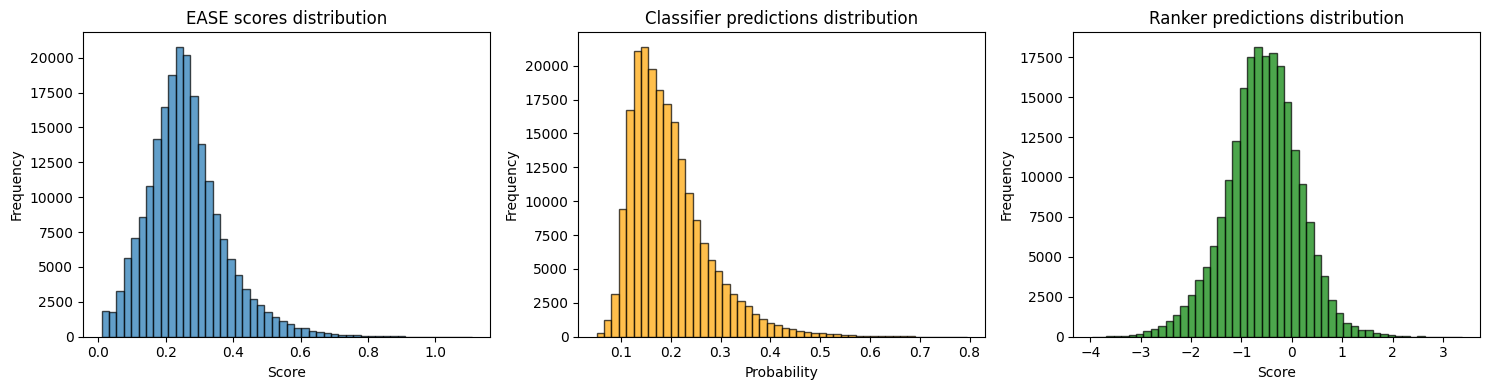


Статистика предсказаний для label=1 (релевантных айтемов):

EASE score:           0.2824 (mean)
Classifier prob:      0.2348 (mean)
Ranker score:         -0.3325 (mean)

Статистика предсказаний для label=0 (нерелевантных айтемов):

EASE score:           0.2564 (mean)
Classifier prob:      0.1916 (mean)
Ranker score:         -0.6156 (mean)

✅ Хороший знак: если для label=1 средние скоры выше, чем для label=0


In [74]:
# Диагностика: сравним распределения предсказаний
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# EASE scores
axes[0].hist(test_bdf['score'], bins=50, alpha=0.7, edgecolor='black')
axes[0].set_title('EASE scores distribution')
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Frequency')

# Classifier predictions
axes[1].hist(test_bdf['boosting_preds'], bins=50, alpha=0.7, color='orange', edgecolor='black')
axes[1].set_title('Classifier predictions distribution')
axes[1].set_xlabel('Probability')
axes[1].set_ylabel('Frequency')

# Ranker predictions
axes[2].hist(test_bdf['ranker_preds'], bins=50, alpha=0.7, color='green', edgecolor='black')
axes[2].set_title('Ranker predictions distribution')
axes[2].set_xlabel('Score')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# Статистика
print("\nСтатистика предсказаний для label=1 (релевантных айтемов):\n")
print(f"EASE score:           {test_bdf[test_bdf.label==1]['score'].mean():.4f} (mean)")
print(f"Classifier prob:      {test_bdf[test_bdf.label==1]['boosting_preds'].mean():.4f} (mean)")
print(f"Ranker score:         {test_bdf[test_bdf.label==1]['ranker_preds'].mean():.4f} (mean)")

print("\nСтатистика предсказаний для label=0 (нерелевантных айтемов):\n")
print(f"EASE score:           {test_bdf[test_bdf.label==0]['score'].mean():.4f} (mean)")
print(f"Classifier prob:      {test_bdf[test_bdf.label==0]['boosting_preds'].mean():.4f} (mean)")
print(f"Ranker score:         {test_bdf[test_bdf.label==0]['ranker_preds'].mean():.4f} (mean)")

print("\n✅ Хороший знак: если для label=1 средние скоры выше, чем для label=0")

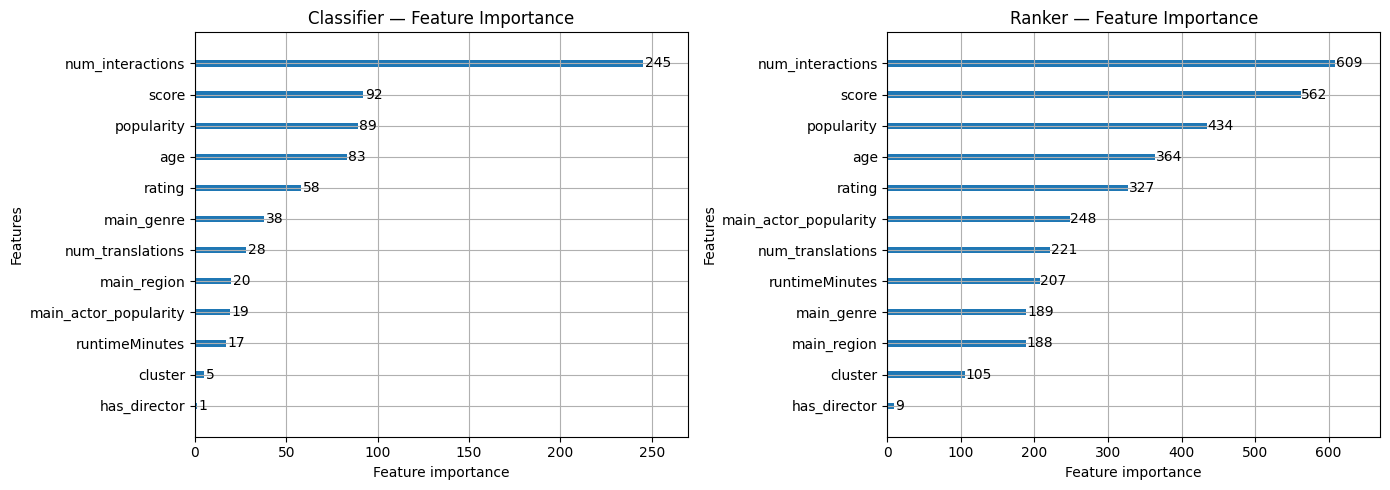

              feature  classifier  ranker
     num_interactions         245     609
                score          92     562
           popularity          89     434
                  age          83     364
               rating          58     327
main_actor_popularity          19     248
     num_translations          28     221
       runtimeMinutes          17     207
           main_genre          38     189
          main_region          20     188
              cluster           5     105
         has_director           1       9
     is_multiregional           0       0


In [75]:
from lightgbm import plot_importance

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_importance(clf, ax=axes[0], title='Classifier — Feature Importance')
plot_importance(ranker, ax=axes[1], title='Ranker — Feature Importance')

plt.tight_layout()
plt.show()

# Числовые значения для удобства
importance_df = pd.DataFrame({
    'feature': FEATURES,
    'classifier': clf.feature_importances_,
    'ranker': ranker.feature_importances_
}).sort_values('ranker', ascending=False)

print(importance_df.to_string(index=False))

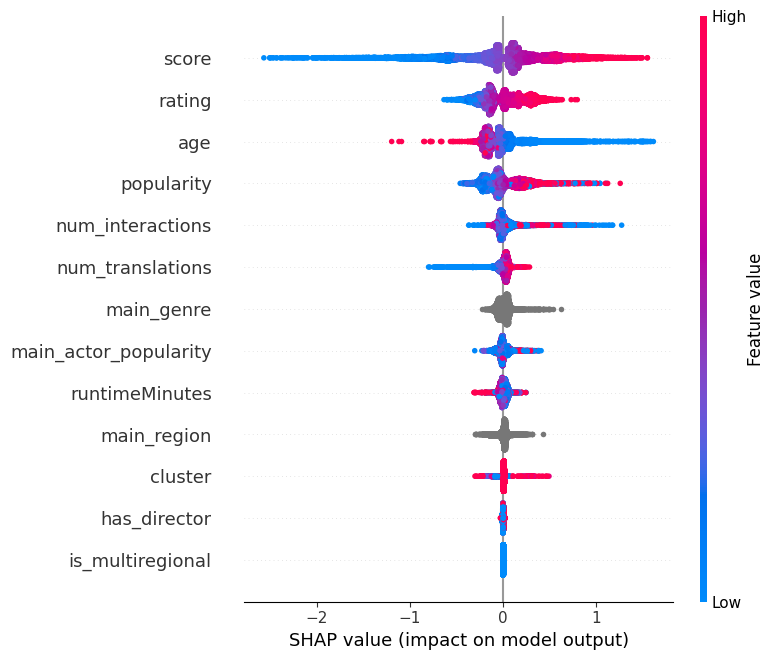

In [76]:
import shap
explainer = shap.TreeExplainer(ranker)
shap_values = explainer.shap_values(test_bdf[FEATURES][:10000])
shap.summary_plot(shap_values, test_bdf[FEATURES][:10000])

Если брать просто актера (аналогично парсить только первое имя из списка) - то это будет сильным якорем для модели, и она перестает обучаться на других признаках. LightGBM (и другие модели) может использовать его как "идентификатор фильма", фактически запоминая конкретные фильмы из трейна, а не обучаясь обобщенным паттернам, что означает утечку данных => Выход: сделать числовую популярность (встречаемость) - main_actor_popularity.
Важность признаков с первым актером:
```
feature  classifier  ranker
      main_actor         253    1199
           score          80     614
num_interactions         193     591
      popularity          62     282
             age          43     197
          rating          32     167
num_translations          14     130
  runtimeMinutes           4      98
         cluster           4      73
      main_genre           7      63
     main_region           8      52
    has_director           0       3
is_multiregional           0       0



### Убираем бесполезные признаки и переобучаем:

In [79]:
# Убираем признаки с нулевой или почти нулевой важностью
FEATURES_V2 = [
    'score',
    'popularity', 
    'age',
    'rating',
    'runtimeMinutes',
    'num_translations',
    'cluster',
    'has_director',
    'num_interactions',
    'main_genre',
    'main_region',
    'main_actor_popularity',
]

# Переобучаем классификатор
clf_v2 = LGBMClassifier(
    max_depth=3, n_estimators=100, learning_rate=0.1,
    random_state=42, n_jobs=-1, verbose=-1
)
clf_v2.fit(X=train_balanced[FEATURES_V2], y=train_balanced['label'])
test_bdf['clf_v2_preds'] = clf_v2.predict_proba(test_bdf[FEATURES_V2])[:, 1]

# Переобучаем ранкер
ranker_v2 = LGBMRanker(
    objective='lambdarank', n_estimators=500,
    max_depth=3, learning_rate=0.1,
    random_state=42, n_jobs=-1, verbose=-1
)
ranker_v2.fit(
    X=train_ranker[FEATURES_V2],
    y=train_ranker['label'],
    group=train_groups,
    eval_set=[(test_ranker[FEATURES_V2], test_ranker['label'])],
    eval_group=[test_groups],
    callbacks=[lgb.log_evaluation(100)]
)
test_bdf['ranker_v2_preds'] = ranker_v2.predict(test_bdf[FEATURES_V2])

print("\nСравнение v1 vs v2:")
print("=" * 60)
for label, col in [('Classifier v1', 'boosting_preds'), 
                    ('Classifier v2', 'clf_v2_preds'),
                    ('Ranker v1    ', 'ranker_preds'),
                    ('Ranker v2    ', 'ranker_v2_preds')]:
    ndcg, prec, rec = evaluate(test_bdf, col, k_ndcg=10, k_prec=15, k_rec=50)
    print(f"{label}: NDCG@10={ndcg:.4f}, P@15={prec:.4f}, R@50={rec:.4f}")

[100]	valid_0's ndcg@1: 0.469655	valid_0's ndcg@2: 0.451869	valid_0's ndcg@3: 0.443941	valid_0's ndcg@4: 0.438958	valid_0's ndcg@5: 0.434712
[200]	valid_0's ndcg@1: 0.471989	valid_0's ndcg@2: 0.456551	valid_0's ndcg@3: 0.445121	valid_0's ndcg@4: 0.439035	valid_0's ndcg@5: 0.435257
[300]	valid_0's ndcg@1: 0.474323	valid_0's ndcg@2: 0.4588	valid_0's ndcg@3: 0.447349	valid_0's ndcg@4: 0.440911	valid_0's ndcg@5: 0.439052
[400]	valid_0's ndcg@1: 0.475257	valid_0's ndcg@2: 0.460075	valid_0's ndcg@3: 0.447165	valid_0's ndcg@4: 0.441751	valid_0's ndcg@5: 0.439317
[500]	valid_0's ndcg@1: 0.481326	valid_0's ndcg@2: 0.46296	valid_0's ndcg@3: 0.44841	valid_0's ndcg@4: 0.444363	valid_0's ndcg@5: 0.441325

Сравнение v1 vs v2:
Classifier v1: NDCG@10=0.5756, P@15=0.2623, R@50=0.6917
Classifier v2: NDCG@10=0.5756, P@15=0.2623, R@50=0.6917
Ranker v1    : NDCG@10=0.5909, P@15=0.2653, R@50=0.7058
Ranker v2    : NDCG@10=0.5909, P@15=0.2653, R@50=0.7058


### Optuna для LGBMRanker:

In [80]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'objective': 'lambdarank',
        'n_estimators': trial.suggest_int('n_estimators', 100, 800),
        'max_depth': trial.suggest_int('max_depth', 2, 6),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 15, 63),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'random_state': 42,
        'n_jobs': -1,
        'verbose': -1,
    }
    
    model = LGBMRanker(**params)
    model.fit(
        X=train_ranker[FEATURES_V2],
        y=train_ranker['label'],
        group=train_groups,
    )
    
    # Оптимизируем NDCG@10 на тестовой выборке
    test_bdf['optuna_preds'] = model.predict(test_bdf[FEATURES_V2])
    ndcg, _, _ = evaluate(test_bdf, 'optuna_preds', k_ndcg=10, k_prec=15, k_rec=50)
    return ndcg

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30, show_progress_bar=True)

print(f"\nЛучший NDCG@10: {study.best_value:.4f}")
print(f"Лучшие параметры:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

  0%|          | 0/30 [00:00<?, ?it/s]


Лучший NDCG@10: 0.5883
Лучшие параметры:
  n_estimators: 384
  max_depth: 3
  learning_rate: 0.09279236111425143
  num_leaves: 50
  min_child_samples: 100
  subsample: 0.8678670130914554
  colsample_bytree: 0.7599352913378673
  reg_alpha: 0.42288158595075614
  reg_lambda: 0.00011336425452708445


### Переобучаем с лучшими параметрами:

In [81]:
best_ranker = LGBMRanker(
    objective='lambdarank',
    **study.best_params,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

best_ranker.fit(
    X=train_ranker[FEATURES_V2],
    y=train_ranker['label'],
    group=train_groups,
    eval_set=[(test_ranker[FEATURES_V2], test_ranker['label'])],
    eval_group=[test_groups],
    callbacks=[lgb.log_evaluation(100)]
)

test_bdf['best_ranker_preds'] = best_ranker.predict(test_bdf[FEATURES_V2])

print("\nФинальное сравнение:")
print("=" * 60)
for label, col in [
    ('EASE baseline   ', 'score'),
    ('EASE + Classifier', 'boosting_preds'),
    ('EASE + Ranker   ', 'ranker_preds'),
    ('EASE + Ranker (Optuna)', 'best_ranker_preds'),
]:
    ndcg, prec, rec = evaluate(test_bdf, col, k_ndcg=10, k_prec=15, k_rec=50)
    print(f"{label}: NDCG@10={ndcg:.4f}, P@15={prec:.4f}, R@50={rec:.4f}")

[100]	valid_0's ndcg@1: 0.468721	valid_0's ndcg@2: 0.455565	valid_0's ndcg@3: 0.443836	valid_0's ndcg@4: 0.437	valid_0's ndcg@5: 0.433579
[200]	valid_0's ndcg@1: 0.471989	valid_0's ndcg@2: 0.454137	valid_0's ndcg@3: 0.444701	valid_0's ndcg@4: 0.438426	valid_0's ndcg@5: 0.435496
[300]	valid_0's ndcg@1: 0.473856	valid_0's ndcg@2: 0.456185	valid_0's ndcg@3: 0.446267	valid_0's ndcg@4: 0.439841	valid_0's ndcg@5: 0.435331

Финальное сравнение:
EASE baseline   : NDCG@10=0.5117, P@15=0.2336, R@50=0.6260
EASE + Classifier: NDCG@10=0.5756, P@15=0.2623, R@50=0.6917
EASE + Ranker   : NDCG@10=0.5909, P@15=0.2653, R@50=0.7058
EASE + Ranker (Optuna): NDCG@10=0.5883, P@15=0.2642, R@50=0.7009


### CatBoost Ranker

In [82]:
from catboost import CatBoostRanker, Pool

CAT_FEATURES = ['main_genre', 'main_region']

# Сбрасываем category dtype обратно в str для CatBoost
train_ranker_cb = train_ranker[FEATURES_V2 + ['label', 'userId']].copy()
test_ranker_cb = test_ranker[FEATURES_V2 + ['label', 'userId']].copy()

for col in CAT_FEATURES:
    train_ranker_cb[col] = train_ranker_cb[col].astype(str)
    test_ranker_cb[col] = test_ranker_cb[col].astype(str)

# CatBoost Pool
train_pool = Pool(
    data=train_ranker_cb[FEATURES_V2],
    label=train_ranker_cb['label'],
    group_id=train_ranker_cb['userId'],
    cat_features=CAT_FEATURES
)

test_pool = Pool(
    data=test_ranker_cb[FEATURES_V2],
    label=test_ranker_cb['label'],
    group_id=test_ranker_cb['userId'],
    cat_features=CAT_FEATURES
)

print("Пулы созданы")
print(f"Train pool: {train_ranker_cb.shape}")
print(f"Test pool:  {test_ranker_cb.shape}")

Пулы созданы
Train pool: (642500, 14)
Test pool:  (214200, 14)


In [83]:
%%time

cb_ranker = CatBoostRanker(
    loss_function='YetiRank',  # аналог lambdarank для CatBoost
    task_type='GPU',
    iterations=500,
    depth=3,
    learning_rate=0.1,
    random_seed=42,
    verbose=100,
)

cb_ranker.fit(
    train_pool,
    eval_set=test_pool,
)

# Предсказания
test_bdf_sorted = test_bdf.sort_values('userId').reset_index(drop=True)
test_bdf_sorted['cb_ranker_preds'] = cb_ranker.predict(test_pool)

print("\n CatBoost Ranker обучен")

Groupwise loss function. OneHotMaxSize set to 10


Default metric period is 5 because PFound is/are not implemented for GPU
Metric PFound is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Metric PFound is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time


0:	test: 0.3776164	best: 0.3776164 (0)	total: 77.9ms	remaining: 38.9s
100:	test: 0.5739273	best: 0.5739273 (100)	total: 3.54s	remaining: 14s
200:	test: 0.5830176	best: 0.5832716 (190)	total: 6.89s	remaining: 10.3s
300:	test: 0.5886783	best: 0.5886783 (300)	total: 10.2s	remaining: 6.76s
400:	test: 0.5907788	best: 0.5911257 (395)	total: 13.6s	remaining: 3.37s
499:	test: 0.5921935	best: 0.5921935 (499)	total: 17s	remaining: 0us
bestTest = 0.5921934836
bestIteration = 499

 CatBoost Ranker обучен
CPU times: user 42.4 s, sys: 3.23 s, total: 45.6 s
Wall time: 18.2 s


In [84]:
print("Финальное сравнение всех моделей:")
print("=" * 65)
for label, col, df in [
    ('EASE baseline    ', 'score',             test_bdf),
    ('EASE + LGB Clf   ', 'boosting_preds',    test_bdf),
    ('EASE + LGB Ranker', 'ranker_preds',      test_bdf),
    ('EASE + CB Ranker ', 'cb_ranker_preds',   test_bdf_sorted),
]:
    ndcg, prec, rec = evaluate(df, col, k_ndcg=10, k_prec=15, k_rec=50)
    print(f"{label}: NDCG@10={ndcg:.4f}, P@15={prec:.4f}, R@50={rec:.4f}")

Финальное сравнение всех моделей:
EASE baseline    : NDCG@10=0.5117, P@15=0.2336, R@50=0.6260
EASE + LGB Clf   : NDCG@10=0.5756, P@15=0.2623, R@50=0.6917
EASE + LGB Ranker: NDCG@10=0.5909, P@15=0.2653, R@50=0.7058
EASE + CB Ranker : NDCG@10=0.5710, P@15=0.2621, R@50=0.6963


In [85]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective_cb(trial):
    params = {
        'loss_function': 'YetiRank',
        'task_type': 'GPU',
        'iterations': trial.suggest_int('iterations', 200, 800),
        'depth': trial.suggest_int('depth', 2, 6),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-3, 10.0, log=True),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
        'random_strength': trial.suggest_float('random_strength', 0.0, 1.0),
        'border_count': trial.suggest_int('border_count', 32, 128),
        'random_seed': 42,
        'verbose': 0,
    }
    
    model = CatBoostRanker(**params)
    model.fit(train_pool)
    
    # Предсказываем
    preds = model.predict(test_pool)
    test_ranker_cb['optuna_cb_preds'] = preds
    
    # Мерджим предсказания обратно в test_bdf по userId + movieId
    temp = test_ranker_cb[['userId', 'optuna_cb_preds']].copy()
    temp.index = test_ranker_cb.index
    
    test_bdf_sorted['optuna_cb_preds'] = preds
    ndcg, _, _ = evaluate(test_bdf_sorted, 'optuna_cb_preds', k_ndcg=10, k_prec=15, k_rec=50)
    
    return ndcg

study_cb = optuna.create_study(direction='maximize')
study_cb.optimize(objective_cb, n_trials=20, show_progress_bar=True)

print(f"\nЛучший NDCG@10: {study_cb.best_value:.4f}")
print(f"Лучшие параметры:")
for k, v in study_cb.best_params.items():
    print(f"  {k}: {v}")

  0%|          | 0/20 [00:00<?, ?it/s]

Default metric period is 5 because PFound is/are not implemented for GPU
Metric PFound is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Metric PFound is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Default metric period is 5 because PFound is/are not implemented for GPU
Metric PFound is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Metric PFound is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Default metric period is 5 because PFound is/are not implemented for GPU
Metric PFound is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Metric PFound is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Default metric period is 5 because PF


Лучший NDCG@10: 0.5840
Лучшие параметры:
  iterations: 768
  depth: 5
  learning_rate: 0.29007493242388144
  l2_leaf_reg: 0.02167611981459905
  bagging_temperature: 0.5935898358557536
  random_strength: 0.587133342311092
  border_count: 44


In [86]:
%%time

best_cb_ranker = CatBoostRanker(
    loss_function='YetiRank',
    task_type='GPU',
    **study_cb.best_params,
    random_seed=42,
    verbose=100,
)

best_cb_ranker.fit(
    train_pool,
    eval_set=test_pool,
)

test_bdf_sorted['best_cb_preds'] = best_cb_ranker.predict(test_pool)

print("\nФинальное сравнение:")
print("=" * 65)
for label, col, df in [
    ('EASE baseline    ', 'score',           test_bdf),
    ('EASE + LGB Clf   ', 'boosting_preds',  test_bdf),
    ('EASE + LGB Ranker', 'ranker_preds',    test_bdf),
    ('EASE + CB Ranker ', 'cb_ranker_preds', test_bdf_sorted),
    ('EASE + CB Ranker(Optuna)', 'best_cb_preds',  test_bdf_sorted),
]:
    ndcg, prec, rec = evaluate(df, col, k_ndcg=10, k_prec=15, k_rec=50)
    print(f"{label}: NDCG@10={ndcg:.4f}, P@15={prec:.4f}, R@50={rec:.4f}")

Groupwise loss function. OneHotMaxSize set to 10


Default metric period is 5 because PFound is/are not implemented for GPU
Metric PFound is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Metric PFound is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time


0:	test: 0.4237118	best: 0.4237118 (0)	total: 91.1ms	remaining: 1m 9s
100:	test: 0.5954319	best: 0.5955159 (95)	total: 4.24s	remaining: 28s
200:	test: 0.6005975	best: 0.6005975 (200)	total: 8.34s	remaining: 23.5s
300:	test: 0.6026922	best: 0.6034766 (280)	total: 12.5s	remaining: 19.3s
400:	test: 0.6038779	best: 0.6039663 (385)	total: 16.6s	remaining: 15.2s
500:	test: 0.6049393	best: 0.6050280 (465)	total: 20.8s	remaining: 11.1s
600:	test: 0.6055264	best: 0.6057047 (565)	total: 24.9s	remaining: 6.93s
700:	test: 0.6053464	best: 0.6059218 (660)	total: 29.2s	remaining: 2.79s
767:	test: 0.6052822	best: 0.6059218 (660)	total: 32s	remaining: 0us
bestTest = 0.6059218154
bestIteration = 660
Shrink model to first 661 iterations.

Финальное сравнение:
EASE baseline    : NDCG@10=0.5117, P@15=0.2336, R@50=0.6260
EASE + LGB Clf   : NDCG@10=0.5756, P@15=0.2623, R@50=0.6917
EASE + LGB Ranker: NDCG@10=0.5909, P@15=0.2653, R@50=0.7058
EASE + CB Ranker : NDCG@10=0.5710, P@15=0.2621, R@50=0.6963
EASE + CB

# ВЫВОДЫ

В ходе проделанной работы была поставлена задача построить двухэтапную рекомендательную систему. На первом этапе модель EASE использовалась для генерации кандидатов для каждого пользователя формировался список из 100 наиболее релевантных объектов. На втором этапе полученные кандидаты дополнительно обрабатывались нелинейной моделью ранжирования, которая учитывала контентные признаки фильмов и переупорядочивала рекомендации.

Подготовка признаков осуществлялась Михаилом. Изначально признаки были сформированы на основе объединения скорингов EASE с контентными метаданными фильмов. В дальнейшем в процессе обучения моделей был проведен дополнительный Feature Engineering, направленный на повышение качества и устойчивости модели.

В первую очередь были удалены малоинформативные признаки, важность которых была определена на основе SHAP анализа. Изначально были исключены has_director и is_multiregional ввиду их малой важности. Однако в конечном варианте has_director решено было оставить, так как без него качество становилось хуже.

Отдельное внимание было уделено проблеме утечки данных. Признак main_actor, содержащий 1221 уникальное значение, мог приводить к переобучению модели на редких актерах. Чтобы сохранить полезный сигнал, но избежать утечки, данный признак был заменен на main_actor_popularity - количество фильмов первого актера в датасете. Такой подход позволил сохранить информацию о популярности актера без избыточной детализации.


Анализ важности признаков показал, что наибольший вклад в качество ранжирования вносят признаки num_interactions (609), score (562), popularity (434), age (364) и rating (327). SHAP аналогичным образом выявил лидерство данных признаков, однако расположил их в другом порядке.

Далее был проведен ряд экспериментов с различными моделями второго этапа, реализацией которых занимался Никита (результаты экспериментов представлены в таблице ниже).

In [14]:
comparison_df

,Модель,NDCG@10,R@50,P@15
0,EASE + LGB Ranker 🏆,0.5909,0.7058,0.2653
1,EASE + CatBoost Ranker (Optuna),0.5862,0.7017,0.2676
2,EASE + LGB Classifier,0.5756,0.6917,0.2623
3,EASE + CatBoost Ranker,0.5710,0.6963,0.2621
4,EASE baseline,0.5117,0.6260,0.2336


Лучшим решением стал LightGBM Ranker с дефолтными гиперпараметрами. Преимущество ранкера объясняется тем, что, в отличие от классификатора, он напрямую оптимизирует порядок рекомендаций внутри группы пользователя с использованием функции lambdarank, что лучше соответствует целевой метрике NDCG. Кроме того, LightGBM эффективно обработал категориальные признаки (main_genre, main_region) и на данном объеме данных показал более стабильную работу по сравнению с CatBoost. Optuna для LGB Ranker не дала прироста - дефолтные параметры уже были близки к оптимуму, что говорит об устойчивости модели

Стоит отметить, что CatBoost с Optuna показал лучший P@15 (0.2676 vs 0.2653), то есть точнее ранжирует середину списка, но уступает LGBM в самом топе, что критичнее для NDCG.

In [13]:
# comparison_df = pd.DataFrame({
#     'Модель': ['EASE baseline', 'EASE + LGB Classifier', 'EASE + CatBoost Ranker',
#                'EASE + CatBoost Ranker (Optuna)', 'EASE + LGB Ranker 🏆'],
#     'NDCG@10': [0.5117, 0.5756, 0.5710, 0.5862, 0.5909],
#     'R@50': [0.6260, 0.6917, 0.6963, 0.7017,0.7058],
#     'P@15': [0.2336, 0.2623, 0.2621, 0.2676, 0.2653],
# })
# comparison_df = comparison_df.sort_values(by = 'NDCG@10', ascending = False).reset_index(drop = True)